In [2]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [3]:
# Menggabungkan semua data dari semua file CSV
dataset = pd.read_csv('D:/KULIAH/TA-DESAK/model/sampling_fix.csv')

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


In [5]:
# Hapus baris yang memiliki NaN di kolom "label"
dataset = dataset.dropna(subset=["Label"])

# Melihat unique value pada kolom "label"
dataset["Label"].unique()

array(['berlebihan', 'nonrelevan', 'relevan'], dtype=object)

In [6]:
dataset[dataset['Title_Summary'].isna()]

,Title_Summary,Label


In [7]:
dataset = dataset.dropna(subset=['Title_Summary'])

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14316 entries, 0 to 14315
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title_Summary  14316 non-null  object
 1   Label          14316 non-null  object
dtypes: object(2)
memory usage: 223.8+ KB


In [8]:
dataset.head(20)

,Title_Summary,Label
0,"Senada dengan JK, Ketua Komisi X Mengaku Sorot...",berlebihan
1,Foto Perdana Baby Arkana Anak Ketiga Nikita Mi...,nonrelevan
2,Ungkapan Hati Tora Sudiro Usai Nikahkan Anak P...,relevan
3,"Kenakan Gaun Mewah, Jennie BLACKPINK Justru Di...",nonrelevan
4,Nadhila QP Ungkap Rahasia Kecantikan Alami di ...,nonrelevan
5,Mpok Alpa Berbagi Kisah Masa Kecil di Kampung ...,nonrelevan
6,"Soal UU KPK, Ketua Kadin: Baik untuk Kepastian...",berlebihan
7,Penjelasan Fuji soal Gaji Eks Manajer Rp 500 R...,relevan
8,Kondisi Terkini Nunung Usai Jalani Operasi Mat...,relevan
9,"NasDem Gabung Pemerintahan Prabowo-Gibran, Beg...",berlebihan


# Delete Karakter

In [9]:
dataset.head(10)

,Title_Summary,Label
0,"Senada dengan JK, Ketua Komisi X Mengaku Sorot...",berlebihan
1,Foto Perdana Baby Arkana Anak Ketiga Nikita Mi...,nonrelevan
2,Ungkapan Hati Tora Sudiro Usai Nikahkan Anak P...,relevan
3,"Kenakan Gaun Mewah, Jennie BLACKPINK Justru Di...",nonrelevan
4,Nadhila QP Ungkap Rahasia Kecantikan Alami di ...,nonrelevan
5,Mpok Alpa Berbagi Kisah Masa Kecil di Kampung ...,nonrelevan
6,"Soal UU KPK, Ketua Kadin: Baik untuk Kepastian...",berlebihan
7,Penjelasan Fuji soal Gaji Eks Manajer Rp 500 R...,relevan
8,Kondisi Terkini Nunung Usai Jalani Operasi Mat...,relevan
9,"NasDem Gabung Pemerintahan Prabowo-Gibran, Beg...",berlebihan


In [10]:
dataset['Title_Summary'] = dataset['Title_Summary'].str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)

In [11]:
dataset.head(10)

,Title_Summary,Label
0,Senada dengan JK Ketua Komisi X Mengaku Sorot...,berlebihan
1,Foto Perdana Baby Arkana Anak Ketiga Nikita Mi...,nonrelevan
2,Ungkapan Hati Tora Sudiro Usai Nikahkan Anak P...,relevan
3,Kenakan Gaun Mewah Jennie BLACKPINK Justru Di...,nonrelevan
4,Nadhila QP Ungkap Rahasia Kecantikan Alami di ...,nonrelevan
5,Mpok Alpa Berbagi Kisah Masa Kecil di Kampung ...,nonrelevan
6,Soal UU KPK Ketua Kadin Baik untuk Kepastian...,berlebihan
7,Penjelasan Fuji soal Gaji Eks Manajer Rp 500 R...,relevan
8,Kondisi Terkini Nunung Usai Jalani Operasi Mat...,relevan
9,NasDem Gabung Pemerintahan Prabowo Gibran Beg...,berlebihan


In [12]:
dataset['Title_Summary'] = dataset['Title_Summary'].str.lower()
dataset.head()

,Title_Summary,Label
0,senada dengan jk ketua komisi x mengaku sorot...,berlebihan
1,foto perdana baby arkana anak ketiga nikita mi...,nonrelevan
2,ungkapan hati tora sudiro usai nikahkan anak p...,relevan
3,kenakan gaun mewah jennie blackpink justru di...,nonrelevan
4,nadhila qp ungkap rahasia kecantikan alami di ...,nonrelevan


# Classification

In [13]:
import os
import re
import string
import numpy as np
import pandas as pd
import nltk
import tensorflow as tf

from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, Adamax, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout
from tensorflow.keras.layers import LSTM, Embedding, Dense, Dropout, SpatialDropout1D
from tensorflow.keras import regularizers

In [14]:
dataset['Label'].value_counts()

Label
relevan       4926
berlebihan    4890
nonrelevan    4500
Name: count, dtype: int64

In [15]:
dataset.groupby(dataset['Label']).count()

,Title_Summary
Label,
berlebihan,4890
nonrelevan,4500
relevan,4926


In [16]:
kategori = pd.get_dummies(dataset.Label)
dataset = pd.concat([dataset, kategori], axis=1)
dataset = dataset.drop(columns='Label')
dataset.sample(5)

,Title_Summary,berlebihan,nonrelevan,relevan
6547,pemerintah asing minta warganya waspada terny...,False,True,False
3399,perjalanan karier musik delon dari dulu hingga...,False,True,False
8299,pesan paus fransiskus di istana perjuangkan h...,False,True,False
14272,transparan tubuhnya daging tersisa tulang meny...,False,True,False
10814,kpk panggil direktur pt sinarmas sekuritas jad...,True,False,False


In [17]:
feature = dataset['Title_Summary']
label = dataset[['berlebihan', 'nonrelevan', 'relevan']].values

In [18]:
from sklearn.model_selection import train_test_split
feature_latih, feature_test, label_latih, label_test = train_test_split(feature, label, test_size=0.2, random_state=42)

In [19]:
pad_type = 'pre'
trunc_type = 'pre'

# Tokenize our training data
tokenizer = Tokenizer(num_words=58700, oov_token='x')

tokenizer.fit_on_texts(feature_latih)

# # Hitung jumlah kata unik + 1 (karena index dimulai dari 1, dan 0 untuk padding)
# vocab_size = len(tokenizer.word_index) + 1
# print("Ukuran kosakata:", vocab_size)

# Encode training data sentences into sequences
sekuens_latih = tokenizer.texts_to_sequences(feature_latih)
sekuens_test = tokenizer.texts_to_sequences(feature_test)

# Get max training sequence length
maxlen = max([len(x) for x in sekuens_latih])

# Pad the training sequences
padded_latih = pad_sequences(sekuens_latih, padding=pad_type, truncating=trunc_type, maxlen=maxlen)
padded_test = pad_sequences(sekuens_test, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

In [20]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=58700, output_dim=64, input_length=maxlen),
    tf.keras.layers.SpatialDropout1D(0.3),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.build(input_shape=(None, maxlen))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 3026, 64)          3756800   
                                                                 
 spatial_dropout1d (SpatialD  (None, 3026, 64)         0         
 ropout1D)                                                       
                                                                 
 bidirectional (Bidirectiona  (None, 3026, 128)        66048     
 l)                                                              
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                        

In [21]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.9 and logs.get('val_accuracy')>0.9):
      print("\nAkurasi telah mencapai >90A%!")
      self.model.stop_training = True
callbacks = myCallback()

In [22]:
num_epochs = 10
hist = model.fit(padded_latih, label_latih, epochs=num_epochs,
                    validation_data=(padded_test, label_test),
                    verbose=2, callbacks=[callbacks])

Epoch 1/10
358/358 - 148s - loss: 1.0952 - accuracy: 0.3697 - val_loss: 1.0849 - val_accuracy: 0.6222 - 148s/epoch - 414ms/step
Epoch 2/10
358/358 - 143s - loss: 0.8387 - accuracy: 0.5719 - val_loss: 0.6524 - val_accuracy: 0.6117 - 143s/epoch - 399ms/step
Epoch 3/10
358/358 - 142s - loss: 0.6505 - accuracy: 0.6388 - val_loss: 0.6184 - val_accuracy: 0.7165 - 142s/epoch - 395ms/step
Epoch 4/10
358/358 - 143s - loss: 0.6242 - accuracy: 0.6584 - val_loss: 0.6165 - val_accuracy: 0.7559 - 143s/epoch - 400ms/step
Epoch 5/10
358/358 - 145s - loss: 0.5402 - accuracy: 0.7283 - val_loss: 0.5591 - val_accuracy: 0.8083 - 145s/epoch - 404ms/step
Epoch 6/10
358/358 - 142s - loss: 0.4753 - accuracy: 0.8088 - val_loss: 0.4782 - val_accuracy: 0.8170 - 142s/epoch - 396ms/step
Epoch 7/10
358/358 - 144s - loss: 0.3662 - accuracy: 0.8613 - val_loss: 0.4844 - val_accuracy: 0.7943 - 144s/epoch - 401ms/step
Epoch 8/10
358/358 - 142s - loss: 0.3054 - accuracy: 0.8890 - val_loss: 0.4310 - val_accuracy: 0.8422 - 

## Confusion Matrix

90/90 [==============================] - 16s 169ms/step


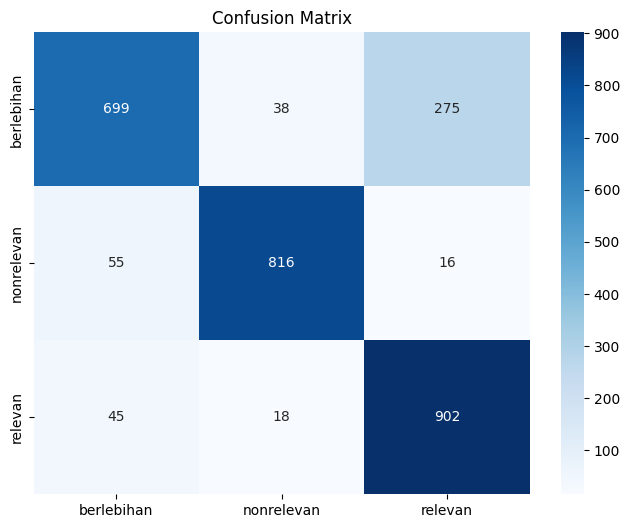

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Prediksi label dari data uji
label_prediksi = model.predict(padded_test)
label_prediksi = [list(prediksi).index(max(prediksi)) for prediksi in label_prediksi]

# Konversi one-hot encoded labels menjadi label kelas tunggal
label_asli = [list(label).index(1) for label in label_test]

# Buat confusion matrix
cm = confusion_matrix(label_asli, label_prediksi)

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['berlebihan', 'nonrelevan', 'relevan'], yticklabels=['berlebihan', 'nonrelevan', 'relevan'])
plt.title('Confusion Matrix')
plt.show()

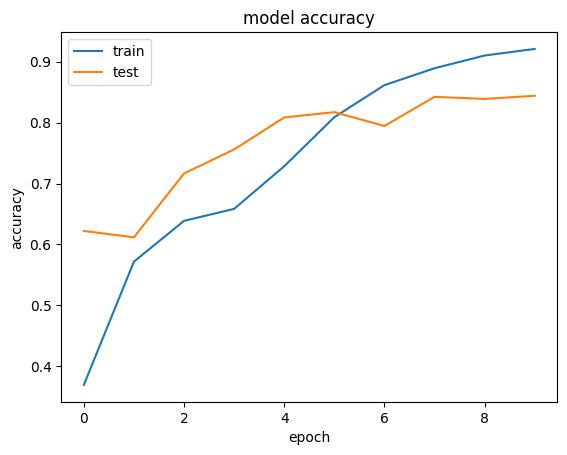

In [24]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

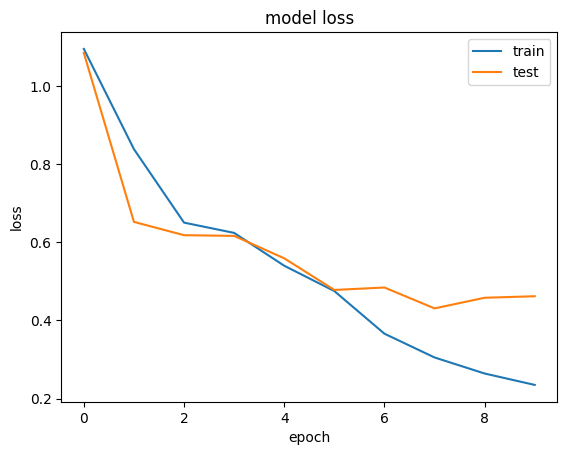

In [25]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Prediksi label dari data uji
label_prediksi = model.predict(padded_test)
label_prediksi = [list(prediksi).index(max(prediksi)) for prediksi in label_prediksi]

# Konversi one-hot encoded labels menjadi label kelas tunggal
label_asli = [list(label).index(1) for label in label_test]

# Hitung akurasi
accuracy = sum([1 for true, pred in zip(label_asli, label_prediksi) if true == pred]) / len(label_asli)
print(f"Akurasi pada data uji: {accuracy * 100:.2f}%")

# Hitung Precision, Recall, dan F1-Score
precision = precision_score(label_asli, label_prediksi, average='weighted')
recall = recall_score(label_asli, label_prediksi, average='weighted')
f1 = f1_score(label_asli, label_prediksi, average='weighted')

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")


90/90 [==============================] - 16s 175ms/step
Akurasi pada data uji: 84.39%
Precision: 0.854
Recall: 0.844
F1-Score: 0.842


In [27]:
from sklearn.metrics import classification_report

# Menghitung Precision, Recall, dan F1-Score
report = classification_report(label_asli, label_prediksi, target_names=['berlebihan', 'nonrelevan', 'relevan'])
print(report)

              precision    recall  f1-score   support

  berlebihan       0.87      0.69      0.77      1012
  nonrelevan       0.94      0.92      0.93       887
     relevan       0.76      0.93      0.84       965

    accuracy                           0.84      2864
   macro avg       0.86      0.85      0.85      2864
weighted avg       0.85      0.84      0.84      2864



## Cross Validation

In [28]:
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf

# Fungsi membuat model LSTM
def create_model(maxlen, vocab_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=maxlen),
        tf.keras.layers.SpatialDropout1D(0.3),

        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
        tf.keras.layers.GlobalMaxPooling1D(),

        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(3, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Fungsi cross-validation
def kfold_cross_validation(X, y, vocab_size, maxlen, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    train_scores = []
    val_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    fold = 1
    for train_idx, val_idx in kf.split(X):
        print(f"\n{'='*20} Fold {fold}/{n_splits} {'='*20}")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = create_model(maxlen, vocab_size)

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ]

        for epoch in range(10):
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=1,
                batch_size=32,
                verbose=1,
                callbacks=callbacks
            )

            train_score = model.evaluate(X_train, y_train, verbose=0)
            val_score = model.evaluate(X_val, y_val, verbose=0)

            y_val_pred = model.predict(X_val)
            y_val_pred_label = []
            for probas in y_val_pred:
                max_proba = np.max(probas)
                max_index = np.argmax(probas)

                if max_proba >= 0.05:
                    y_val_pred_label.append(max_index)
                else:
                    y_val_pred_label.append(-1)

            y_val_true = [np.argmax(p) for p in y_val]

            precision = precision_score(y_val_true, y_val_pred_label, average='weighted', zero_division=0)
            recall = recall_score(y_val_true, y_val_pred_label, average='weighted', zero_division=0)
            f1 = f1_score(y_val_true, y_val_pred_label, average='weighted', zero_division=0)

            print(f"Epoch {epoch+1} | Train Acc: {train_score[1]:.4f}, Val Acc: {val_score[1]:.4f}")
            print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

        # Agregat hasil untuk setiap fold
        train_scores.append(train_score[1])
        val_scores.append(val_score[1])
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        # Print hasil akhir fold
        print(f"\n📊 Hasil akhir Fold {fold}")
        print(f"Train Accuracy : {train_score[1]:.4f}")
        print(f"Val Accuracy   : {val_score[1]:.4f}")
        print(f"Precision      : {precision:.4f}")
        print(f"Recall         : {recall:.4f}")
        print(f"F1 Score       : {f1:.4f}")

        # Simpan model
        model.save(f"lstm_fold_{fold}.h5")
        print(f"Model untuk Fold {fold} berhasil disimpan sebagai lstm_fold_{fold}.h5")
        
        fold += 1

    # Cross-validation results
    print("\n====== Ringkasan Hasil Cross Validation ======")
    print(f"Mean Train Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
    print(f"Mean Val Accuracy  : {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")
    print(f"Mean Precision     : {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
    print(f"Mean Recall        : {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
    print(f"Mean F1-Score      : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"Mean Train - Val   : {np.mean(np.array(train_scores) - np.array(val_scores)):.4f}")

# Contoh pemanggilan (pastikan X dan y sudah dalam bentuk array dan sesuai)
X = np.array(padded_latih)
y = np.array(label_latih)
kfold_cross_validation(X, y, vocab_size=58700, maxlen=maxlen, n_splits=5)


==================== Fold 1/5 ====================
72/72 [==============================] - 13s 167ms/step
Epoch 1 | Train Acc: 0.3528, Val Acc: 0.3536
Precision: 0.6596, Recall: 0.3536, F1: 0.1869
72/72 [==============================] - 12s 172ms/step
Epoch 2 | Train Acc: 0.6178, Val Acc: 0.6115
Precision: 0.7427, Recall: 0.6115, F1: 0.4879
72/72 [==============================] - 12s 168ms/step
Epoch 3 | Train Acc: 0.6884, Val Acc: 0.6473
Precision: 0.7369, Recall: 0.6473, F1: 0.6239
72/72 [==============================] - 12s 167ms/step
Epoch 4 | Train Acc: 0.8304, Val Acc: 0.7804
Precision: 0.7772, Recall: 0.7804, F1: 0.7751
72/72 [==============================] - 12s 166ms/step
Epoch 5 | Train Acc: 0.8220, Val Acc: 0.7726
Precision: 0.8005, Recall: 0.7726, F1: 0.7626
72/72 [==============================] - 12s 166ms/step
Epoch 6 | Train Acc: 0.8936, Val Acc: 0.8333
Precision: 0.8380, Recall: 0.8333, F1: 0.8314
72/72 [==============================] - 12s 165ms/step
Epoch 7 | 

## Save Model

In [29]:
import pickle
# Save the model to a file
model.save('modellstm_fixcoba.h5')

# Save the tokenizer to a file using pickle
with open('tokenizer_fixcoba.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Evaluasi 

## ROC-Curve

In [30]:
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [31]:
# 1. Load tokenizer
with open('tokenizer_fixcoba.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

# 2. Tokenisasi dan padding untuk feature_test
sekuens_test = tokenizer.texts_to_sequences(feature_test)

# Gunakan pad_type, trunc_type, dan maxlen yang sama seperti training
pad_type = 'pre'
trunc_type = 'pre'
maxlen = max([len(x) for x in tokenizer.texts_to_sequences(feature_latih)])  # <- Sama seperti saat training

padded_test = pad_sequences(sekuens_test, padding=pad_type, truncating=trunc_type, maxlen=maxlen)

# 3. Load model
model = load_model('modellstm_fixcoba.h5')

# 4. Prediksi probabilitas
y_score = model.predict(padded_test)

90/90 [==============================] - 16s 169ms/step


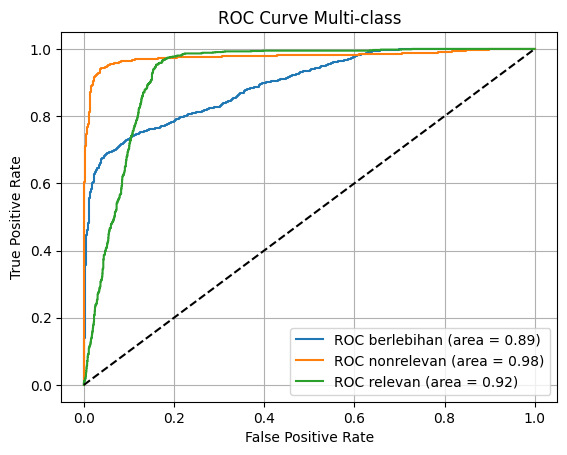

In [32]:

target_names = ['berlebihan', 'nonrelevan', 'relevan']
n_target = len(target_names)

# Binarisasi label_test (kalau label_test kamu berupa angka: 0, 1, 2)
y_true = label_binarize(label_test, classes=range(n_target))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_target):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'ROC {target_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multi-class')
plt.legend(loc='lower right')
plt.grid()
plt.show()